In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 342, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 342 (delta 96), reused 92 (delta 45), pack-reused 159 (from 1)
Receiving objects: 100% (342/342), 7.44 MiB | 17.01 MiB/s, done.
Resolving deltas: 100% (158/158), done.


In [2]:
# local files
from src import utils, plotting
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet
from src.resunet import ResUNetEncoderBlock
from src.bbbc038_dataset import BBBC038Dataset
from src.center_offset_dataset import CenterOffsetDataset

import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-13 19:19:31--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  90.9MB/s    in 0.9s    

2026-09-13 19:19:32 (90.9 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [5]:
# O carregamento está implementado em src/bbbc038_dataset.py.
# Com is_training=True o retorno é:
# sample_id, image, semantic_mask, instance_map
IMG_SIZE = 128


In [6]:
class SharedMaxPoolEncoder(nn.Module):

    def __init__(self, in_channels=3):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)

        self.enc1 = ResUNetEncoderBlock(64, 128, stride=1)

        self.enc2 = ResUNetEncoderBlock(128, 256, stride=1)

        self.bridge = ResUNetEncoderBlock(256, 512, stride=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

    def forward(self, x):

        out0 = self.enc0(x)
        size0 = out0.size()
        pooled0, indices0 = self.pool(out0)

        out1 = self.enc1(pooled0)
        size1 = out1.size()
        pooled1, indices1 = self.pool(out1)

        out2 = self.enc2(pooled1)
        size2 = out2.size()
        pooled2, indices2 = self.pool(out2)

        encoded = self.bridge(pooled2)

        return {
            "encoded": encoded,
            "skips": (out0, out1, out2),
            "indices": (indices0, indices1, indices2),
            "sizes": (size0, size1, size2),
        }

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Antes del pooling: (1, 64, 128, 128)
Después del pooling: (1, 64, 64, 64)


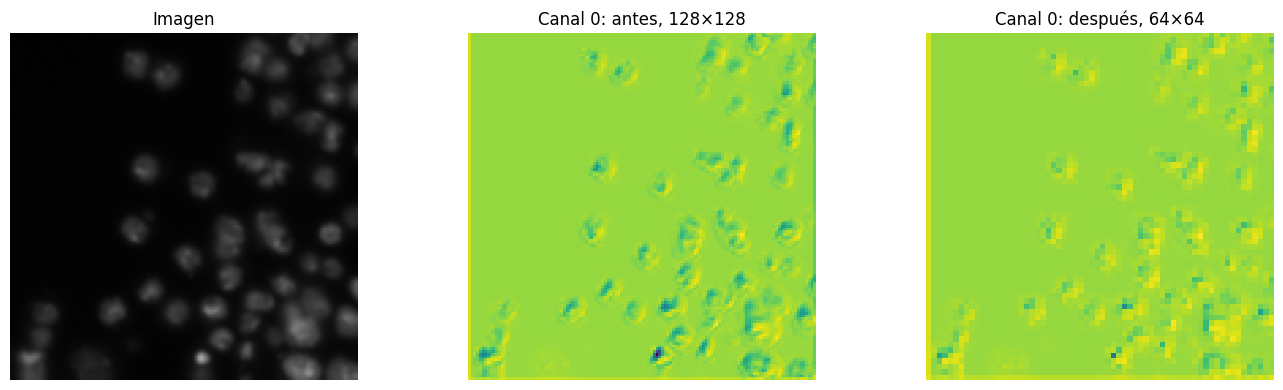

In [8]:
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights_path = Path("/content/deep-learning-pa1/weights/weights_20260913_190326.zip")

model = ResUNet(3, 3).to(device)

state_dict = torch.load(
    weights_path,
    map_location=device,
    weights_only=True
)

model.load_state_dict(state_dict)
model.eval()

base_dataset = BBBC038Dataset(
    is_training=True,
    path="./data/stage1_train",
    img_size=128
)

center_dataset = CenterOffsetDataset(base_dataset)

image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)

print("ID:", image_id)
print("Antes del pooling:", tuple(features.shape))
print("Después del pooling:", tuple(pooled.shape))

channel = 0

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image.permute(1, 2, 0).cpu().numpy())
axes[0].set_title("Imagen")

axes[1].imshow(
    before,
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[1].set_title(f"Canal {channel}: antes, 128×128")

axes[2].imshow(
    after,
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[2].set_title(f"Canal {channel}: después, 64×64")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

model.eval()

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)


In [10]:
print("Antes:", tuple(features.shape))
print("Depois:", tuple(pooled.shape))

Antes: (1, 64, 128, 128)
Depois: (1, 64, 64, 64)


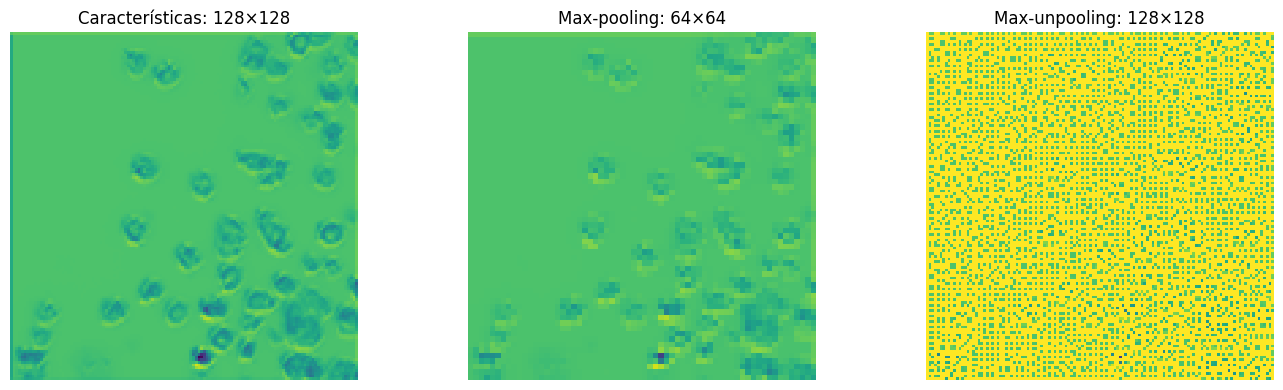

In [11]:
unpool = nn.MaxUnpool2d(
    kernel_size=2,
    stride=2
)

with torch.no_grad():
    restored = unpool(
        pooled,
        indices,
        output_size=features.size()
    )

channel = 63

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()
unpooled = restored[0, channel].cpu().numpy()

vmin = min(before.min(), 0.0)
vmax = max(before.max(), 0.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, values, title in zip(
    axes,
    [before, after, unpooled],
    [
        "Características: 128×128",
        "Max-pooling: 64×64",
        "Max-unpooling: 128×128"
    ]
):
    ax.imshow(
        values,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
class MaxUnpoolDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.projection = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

        self.unpool = nn.MaxUnpool2d(
            kernel_size=2,
            stride=2
        )

        self.refine = ResUNetEncoderBlock(
            out_channels,
            out_channels,
            stride=1
        )

    def forward(self, x, indices, output_size):
        x = self.projection(x)

        x = self.unpool(
            x,
            indices,
            output_size=output_size
        )

        return self.refine(x)

In [13]:
class CenterOffsetMaxUnpool(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = SharedMaxPoolEncoder(
            in_channels=in_channels
        )

        self.dec2 = MaxUnpoolDecoderBlock(512, 256)
        self.dec1 = MaxUnpoolDecoderBlock(256, 128)
        self.dec0 = MaxUnpoolDecoderBlock(128, 64)

        # Canal 0: heatmap
        # Canal 1: dx
        # Canal 2: dy
        self.ending = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )

    def forward(self, x):
        features = self.encoder(x)

        indices0, indices1, indices2 = features["indices"]
        size0, size1, size2 = features["sizes"]

        y = features["encoded"]

        # Recuperar resolucao
        y = self.dec2(y, indices2, size2)
        y = self.dec1(y, indices1, size1)
        y = self.dec0(y, indices0, size0)

        return self.ending(y)

In [14]:
unpool_model = CenterOffsetMaxUnpool().to(device)
unpool_model.eval()

sample_id, image, heatmap, offsets, offset_mask = center_dataset[6]

with torch.no_grad():
    prediction = unpool_model(
        image.unsqueeze(0).to(device)
    )

expected_shape = (1, 3, *image.shape[-2:])

assert tuple(prediction.shape) == expected_shape

print("ID:", sample_id)
print("Salida:", tuple(prediction.shape))
print("Heatmap:", tuple(prediction[:, 0:1].shape))
print("Offsets:", tuple(prediction[:, 1:3].shape))

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Salida: (1, 3, 128, 128)
Heatmap: (1, 1, 128, 128)
Offsets: (1, 2, 128, 128)


In [15]:
from src.resunet import ResUNetDecoderBlock


class CenterOffsetSkip(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = SharedMaxPoolEncoder(in_channels)

        self.dec2 = ResUNetDecoderBlock(512, 256, 256)
        self.dec1 = ResUNetDecoderBlock(256, 128, 128)
        self.dec0 = ResUNetDecoderBlock(128, 64, 64)

        self.ending = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        out0, out1, out2 = features['skips']

        y = features['encoded']
        y = self.dec2(y, out2)
        y = self.dec1(y, out1)
        y = self.dec0(y, out0)

        return self.ending(y)


In [16]:
class ImagePoolingContext(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Conv2d(512, 128, kernel_size=1)
        self.fuse = nn.Conv2d(512 + 128, 512, kernel_size=1)

    def forward(self, x):
        context = self.pool(x)
        context = F.relu(self.projection(context))

        context = F.interpolate(
            context,
            size=x.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        x = torch.cat([x, context], dim=1)
        return F.relu(self.fuse(x))


In [17]:
class CenterOffsetSkipContext(CenterOffsetSkip):
    def __init__(self, in_channels=3):
        super().__init__(in_channels)
        self.context = ImagePoolingContext()

    def forward(self, x):
        features = self.encoder(x)
        out0, out1, out2 = features['skips']

        y = self.context(features['encoded'])
        y = self.dec2(y, out2)
        y = self.dec1(y, out1)
        y = self.dec0(y, out0)

        return self.ending(y)


In [19]:
from torch.utils.data import Subset

train_dataset, val_dataset, test_dataset = random_split(
    center_dataset,
    [0.8, 0.1, 0.1],
    generator=torch.Generator().manual_seed(42)
)

print('Treino:', len(train_dataset))
print('Validacao:', len(val_dataset))
print('Teste:', len(test_dataset))

output_dir = Path('./outputs/parte3_simples')
output_dir.mkdir(parents=True, exist_ok=True)

split_rows = []
for split_name, subset in [
    ('train', train_dataset),
    ('val', val_dataset),
    ('test', test_dataset)
]:
    for index in subset.indices:
        split_rows.append({
            'split': split_name,
            'index': index,
            'image_id': base_dataset.ids[index]
        })

split_df = pd.DataFrame(split_rows)
split_path = output_dir / 'split.csv'
if split_path.exists():
    saved_split = pd.read_csv(split_path)
    assert saved_split.equals(split_df), 'A divisão mudou. Use outra pasta de resultados.'
else:
    split_df.to_csv(split_path, index=False)


Treino: 536
Validacao: 67
Teste: 67


In [20]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def build_models(seed):
    set_seed(seed)
    skip = CenterOffsetSkip()

    set_seed(seed)
    max_unpool = CenterOffsetMaxUnpool()

    set_seed(seed)
    skip_context = CenterOffsetSkipContext()

    max_unpool.encoder.load_state_dict(skip.encoder.state_dict())
    max_unpool.ending.load_state_dict(skip.ending.state_dict())

    skip_context.encoder.load_state_dict(skip.encoder.state_dict())
    skip_context.ending.load_state_dict(skip.ending.state_dict())
    skip_context.dec2.load_state_dict(skip.dec2.state_dict())
    skip_context.dec1.load_state_dict(skip.dec1.state_dict())
    skip_context.dec0.load_state_dict(skip.dec0.state_dict())

    return {
        'skip': skip,
        'max_unpool': max_unpool,
        'skip_context': skip_context
    }


In [21]:
models = build_models(42)
parameter_rows = []

for name, current_model in models.items():
    current_model.eval()

    with torch.no_grad():
        output = current_model(image.unsqueeze(0).cpu())

    assert output.shape == (1, 3, IMG_SIZE, IMG_SIZE)
    print(name, tuple(output.shape))

    parameter_rows.append({
        'architecture': name,
        'parameters': sum(p.numel() for p in current_model.parameters())
    })

parameters_df = pd.DataFrame(parameter_rows)
parameters_df.to_csv(output_dir / 'parameters.csv', index=False)
display(parameters_df)

del models, current_model, output

model.cpu()
unpool_model.cpu()


skip (1, 3, 128, 128)
max_unpool (1, 3, 128, 128)
skip_context (1, 3, 128, 128)


,architecture,parameters
0,skip,11318601
1,max_unpool,6671497
2,skip_context,11712457


CenterOffsetMaxUnpool(
  (encoder): SharedMaxPoolEncoder(
    (enc0): ResUNetEncoderBlock(
      (seq): Sequential(
        (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU()
        (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (shortcut): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (enc1): ResUNetEncoderBlock(
      (seq): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU()
        (5): Conv2d(128, 128, kernel_size=(3, 3), stride

mesma perda

In [22]:
heatmap_loss_fn = nn.MSELoss()
offset_loss_fn = nn.L1Loss(reduction='none')
offset_loss_weight = 1.0


def compute_loss(pred, heatmap, offsets, offset_mask):
    pred_heatmap = pred[:, 0:1]
    pred_offsets = pred[:, 1:3]

    loss_heatmap = heatmap_loss_fn(pred_heatmap, heatmap)

    raw_offset_loss = offset_loss_fn(pred_offsets, offsets)
    mask_2ch = offset_mask.expand_as(raw_offset_loss)

    loss_offsets = (
        (raw_offset_loss * mask_2ch).sum()
        / mask_2ch.sum().clamp(min=1.0)
    )

    return loss_heatmap + offset_loss_weight * loss_offsets
